In [2]:
# Importing  useFul Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [1]:
# loading the Data set From My Global Folder 

df=pd.read_csv('../datasets/Salary_Data.csv')

# For checking i will show just sample data for 3 rows 
df.sample(3)



NameError: name 'pd' is not defined

In [4]:
# Now Checking The Data 
df.shape  # (30 , 2)
df.isnull().sum() # 0 null 

print(df.duplicated().sum()) # 0 Duplicated 


0


In [13]:
X = df[["YearsExperience"]]
X.shape
print(X.sample(3))

Y = df["Salary"]
print(Y.sample(3))

    YearsExperience
27              9.6
13              4.1
12              4.0
8      64445.0
21     98273.0
26    116969.0
Name: Salary, dtype: float64


In [14]:

from sklearn.model_selection import train_test_split

X_train , X_test, Y_train , Y_test = train_test_split(X,Y,test_size=0.3)

print(X_train.sample(2))

print(X_test.sample(2))

print(Y_train.sample(2))

print(Y_test.sample(2))




    YearsExperience
8               3.2
10              3.9
    YearsExperience
2               1.5
24              8.7
3    43525.0
4    39891.0
Name: Salary, dtype: float64
24    109431.0
2      37731.0
Name: Salary, dtype: float64


In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, Y_train)




,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9405.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.697e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:

Y_prediction = lr.predict(X_test)
print(Y_prediction)

[ 74935.70169394  41076.8190066  123842.97668676  82459.89784668
  76816.75073213  64589.93198392 125724.02572495  64589.93198392
 108794.58438128]


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(Y_test, Y_prediction)
print("MAE:", mae)   # in this an average errors are calculated

# like mara pas 3 numbers hae un ma errors : 4 , 6 and 2 ha then 4+6+2/3 = 12/3 = 4 answer aae ga 

MAE: 4665.549979264364


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, Y_prediction)
print("MSE:", mse)  # (actual - prediction )*2/n

MSE: 31559669.512995556


In [20]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 5617.79934787596


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_prediction)
print("R2 Score:", r2)  # how Well model Explain the data 
# Answer: 0.96 - mean 96% accuracy 

R2 Score: 0.962142224990911


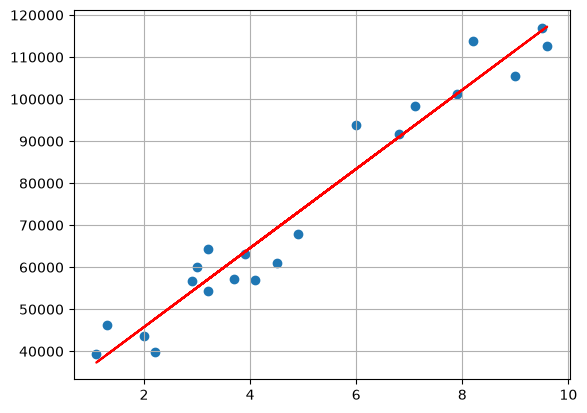

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_train, Y_train)
plt.plot(X_train, lr.predict(X_train), color="red")
plt.grid()
plt.show()

In [23]:
import pickle

pickle.dump(lr, open("salary_model.pkl", "wb"))

## MY OBSERVATION 

In [ ]:
# Meri observation yeh hai ke 1 year experience wala employee bhi kabhi 3 years experience wale se zyada salary le raha hai.
# Iska matlab salary sirf experience se decide nahi hoti. Isi liye Linear Regression har point ko match nahi karta,
# balke sab points ka average trend follow karke best fit line banata hai.